# Task 3 — Demand Forecasting with Feed-Forward Neural Network

In [4]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import product

import keras
from keras import models, layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make scripts/ importable
path = os.getcwd()
while ".git" not in os.listdir(path):
    path = os.path.dirname(path)
os.chdir(Path(path))

from scripts.helpers.modelling import prepare_modelling

SEED = 42
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

# ── Spatio-temporal resolution ────────────────────────────────────────────────
RESOLUTION = 6   # H3 resolution (6 = ~coarse, 7 = ~fine)
FREQ_HOURS = 4   # time bucket width in hours (must match freq below)
# ──────────────────────────────────────────────────────────────────────────────

In [5]:
# Make scripts/ importable
path = os.getcwd()
while ".git" not in os.listdir(path):
    path = os.path.dirname(path)
ROOT_DIR = Path(path)
os.chdir(ROOT_DIR)

In [7]:
from scripts.helpers.modelling import prepare_modelling

df = prepare_modelling(resolution=RESOLUTION, freq=f'{FREQ_HOURS}h')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 132756 entries, 0 to 132755
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   h3_id                 132756 non-null  string        
 1   time_bucket           132756 non-null  datetime64[us]
 2   trip_count            132756 non-null  int64         
 3   is_weekend            132756 non-null  bool          
 4   is_holiday            132756 non-null  bool          
 5   hour_sin              132756 non-null  Float64       
 6   hour_cos              132756 non-null  Float64       
 7   day_of_week_sin       132756 non-null  Float64       
 8   day_of_week_cos       132756 non-null  Float64       
 9   month_sin             132756 non-null  Float64       
 10  month_cos             132756 non-null  Float64       
 11  temperature_2m        132756 non-null  float64       
 12  apparent_temperature  132756 non-null  float64       
 13  precipitat

#### Data & feature preparation

Target — `log1p(trip_count)`. Demand is a heavily zero-inflated, right-skewed count, so the log scale stabilises.

Spatial information — one-hot hexagon id => Binary cols (0/1).

Split — random 50 / 20 / 30. Rows are shuffled.

**For further comments look into the SVM notebook, since assumptions are set to be highly comparable.**

In [8]:
# Prediction-Target: log1p-transformed trip count (invert with np.expm1 for interpretable metrics)
y = np.log1p(df['trip_count'])

drop_cols = ['h3_id', 'time_bucket', 'trip_count']

# Spatial encoding: one-hot hexagon id — gives binary column for each cell
hex_ohe = pd.get_dummies(df['h3_id'], prefix='hex', dtype=float)

# Add the one-hot hexagon encoding binary features as a column to the dataframe
x = pd.concat(
    [df.drop(columns=drop_cols), hex_ohe],
    axis=1,
).astype(float)

print(f"Feature matrix: {x.shape[0]:,} rows × {x.shape[1]} features")

Feature matrix: 132,756 rows × 50 features


In [33]:
#x.info

In [34]:
# Random 50 / 20 / 30 split — mirrors the SVM notebook for a fair comparison
train_idx, temp_idx = train_test_split(df.index, train_size=0.50, random_state=SEED, shuffle=True)
val_idx,   test_idx = train_test_split(temp_idx, train_size=0.40, random_state=SEED, shuffle=True)

x_train, y_train = x.loc[train_idx], y.loc[train_idx]
x_val,   y_val   = x.loc[val_idx],   y.loc[val_idx]
x_test,  y_test  = x.loc[test_idx],  y.loc[test_idx]

print(f"train {len(x_train):>7,}  ({len(x_train)/len(df):.0%})")
print(f"val   {len(x_val):>7,}  ({len(x_val)/len(df):.0%})")
print(f"test  {len(x_test):>7,}  ({len(x_test)/len(df):.0%})")

train  66,378  (50%)
val    26,551  (20%)
test   39,827  (30%)


StandardScaler normalises all features to zero mean and unit variance,
ensuring no single feature dominates the gradient updates due to its scale

In [35]:
# Fit scaler on train only, then transform all splits
scaler = StandardScaler()

X_train_s = scaler.fit_transform(x_train)
X_val_s   = scaler.transform(x_val)
X_test_s  = scaler.transform(x_test)

INPUT_DIM = X_train_s.shape[1]
print(f"Input dim: {INPUT_DIM}")

Input dim: 50


#### Model architecture

A fully-connected Keras Sequential model with:
- configurable depth, width, and activation
- BatchNormalization after each hidden layer
- Dropout for regularisation
- a single linear output neuron (predicting log1p demand)

In [36]:
def build_model(hidden_dims, dropout=0.2, activation='relu', lr=1e-3, optimizer='adam'):
    """Build and compile a Keras Sequential FFNN for demand regression."""
    opt = keras.optimizers.Adam(lr) if optimizer == 'adam' else keras.optimizers.SGD(lr)

    model = models.Sequential()
    model.add(layers.Input(shape=(INPUT_DIM,)))
    for h in hidden_dims:
        model.add(layers.Dense(h))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation(activation))
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1))  # linear output for regression

    model.compile(optimizer=opt, loss='mse')
    return model
    # mse, poisson wegen counts, squared error, absolute error

# Quick sanity check
# build_model([32, 16]).summary()

#### Hyperparameter grid search

| Parameter | Values tried |
|---|---|
| hidden layer sizes | `[128,64]`, `[256,128]`, `[256,128,64]` |
| dropout | `0.1`, `0.2`, `0.3` |
| learning rate | `0.1`, `0.01`, `0.001` |
| optimizer | `sgd`, `adam` |

Models are trained on `train` and scored on `val`. The best combination is then
retrained on `train+val` (Section 5).

> **Runtime note:** the grid runs 3×3×3×2 = 54 fits. Reduce `epochs` or narrow the grid
> if iteration speed matters.

In [37]:
# ── Hyperparameter grid ────────────────────────────────────────────────────────
HIDDEN_CONFIGS = [[128, 64], [256, 128]]
# Potential Add for sophisticated training [64, 64, 64, 64], [512, 256, 128]
DROPOUTS       = [0.0, 0.1, 0.2]
LRS            = [0.1, 0.01, 0.001] # 0,0001
OPTIMIZERS     = ['sgd']
# ', 'adam'
# ──────────────────────────────────────────────────────────────────────────────

best_val_mae, best_config = np.inf, None
grid_results = []

es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)

for hidden, drop, lr, opt in product(HIDDEN_CONFIGS, DROPOUTS, LRS, OPTIMIZERS):
    m = build_model(hidden, dropout=drop, lr=lr, optimizer=opt)
    m.fit(
        X_train_s, y_train.values,
        validation_data=(X_val_s, y_val.values),
        epochs=100, batch_size=1024, #265
        callbacks=[es], verbose=0,
    )
    pred = np.expm1(m.predict(X_val_s, verbose=0).squeeze())
    val_mae = mean_absolute_error(np.expm1(y_val.values), pred)
    grid_results.append({'hidden': hidden, 'dropout': drop, 'lr': lr,
                         'optimizer': opt, 'val_MAE': round(val_mae, 3)})
    print(f"hidden={hidden}  drop={drop}  lr={lr}  opt={opt}  →  val MAE={val_mae:.3f}")
    if val_mae < best_val_mae:
        best_val_mae, best_config = val_mae, {'hidden': hidden, 'dropout': drop, 'lr': lr, 'optimizer': opt}

grid_df = pd.DataFrame(grid_results).sort_values('val_MAE')
print(f"\nBest config: {best_config}  →  val MAE={best_val_mae:.3f}")
grid_df

hidden=[128, 64]  drop=0.0  lr=0.1  opt=sgd  →  val MAE=11.876
hidden=[128, 64]  drop=0.0  lr=0.01  opt=sgd  →  val MAE=40.942
hidden=[128, 64]  drop=0.0  lr=0.001  opt=sgd  →  val MAE=43.985
hidden=[128, 64]  drop=0.1  lr=0.1  opt=sgd  →  val MAE=38.905
hidden=[128, 64]  drop=0.1  lr=0.01  opt=sgd  →  val MAE=37.623
hidden=[128, 64]  drop=0.1  lr=0.001  opt=sgd  →  val MAE=43.622
hidden=[128, 64]  drop=0.2  lr=0.1  opt=sgd  →  val MAE=35.068
hidden=[128, 64]  drop=0.2  lr=0.01  opt=sgd  →  val MAE=41.634
hidden=[128, 64]  drop=0.2  lr=0.001  opt=sgd  →  val MAE=43.997
hidden=[256, 128]  drop=0.0  lr=0.1  opt=sgd  →  val MAE=232.775
hidden=[256, 128]  drop=0.0  lr=0.01  opt=sgd  →  val MAE=43.113
hidden=[256, 128]  drop=0.0  lr=0.001  opt=sgd  →  val MAE=44.364
hidden=[256, 128]  drop=0.1  lr=0.1  opt=sgd  →  val MAE=170.906
hidden=[256, 128]  drop=0.1  lr=0.01  opt=sgd  →  val MAE=42.801
hidden=[256, 128]  drop=0.1  lr=0.001  opt=sgd  →  val MAE=44.385
hidden=[256, 128]  drop=0.2  lr=

,hidden,dropout,lr,optimizer,val_MAE
0,"[128, 64]",0.0,0.100,sgd,11.876
6,"[128, 64]",0.2,0.100,sgd,35.068
4,"[128, 64]",0.1,0.010,sgd,37.623
3,"[128, 64]",0.1,0.100,sgd,38.905
1,"[128, 64]",0.0,0.010,sgd,40.942
7,"[128, 64]",0.2,0.010,sgd,41.634
13,"[256, 128]",0.1,0.010,sgd,42.801
16,"[256, 128]",0.2,0.010,sgd,42.922
10,"[256, 128]",0.0,0.010,sgd,43.113
5,"[128, 64]",0.1,0.001,sgd,43.622


#### Activation function comparison

Using the best hyperparameters from the grid, we train one model per activation function
and compare their training loss curves. Architecture and optimizer are held fixed.

    RELU  →  val MAE=11.914
    TANH  →  val MAE=28.297
 SIGMOID  →  val MAE=43.506


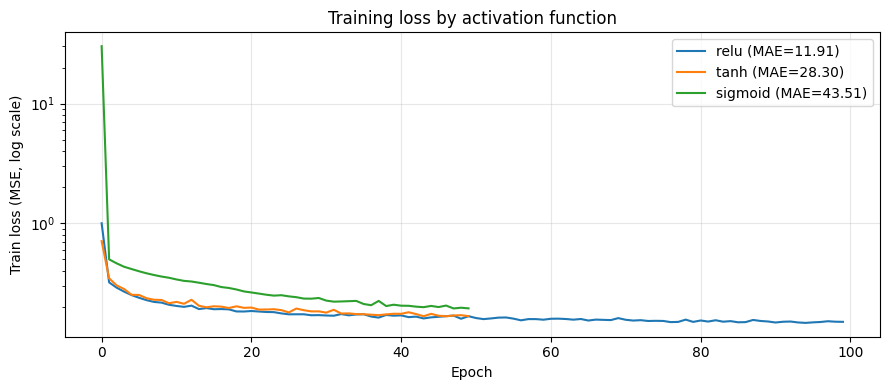

In [38]:
BEST_HIDDEN  = best_config['hidden']
BEST_DROPOUT = best_config['dropout']
BEST_LR      = best_config['lr']
BEST_OPT     = best_config['optimizer']
# Batch Size 128, 265, 512
# weight decay

ACTIVATIONS = ['relu', 'tanh', 'sigmoid']
act_results = {}
es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

for act_name in ACTIVATIONS:
    m = build_model(BEST_HIDDEN, dropout=BEST_DROPOUT, activation=act_name,
                    lr=BEST_LR, optimizer=BEST_OPT)
    hist = m.fit(
        X_train_s, y_train.values,
        validation_data=(X_val_s, y_val.values),
        epochs=100, batch_size=1024,
        callbacks=[es], verbose=0,
    )
    pred = np.expm1(m.predict(X_val_s, verbose=0).squeeze())
    pred = np.nan_to_num(pred, nan=1e9, posinf=1e9, neginf=1e9)
    val_mae = mean_absolute_error(np.expm1(y_val.values), pred)
    act_results[act_name] = {'losses': hist.history['loss'], 'val_MAE': val_mae}
    print(f"{act_name.upper():>8}  →  val MAE={val_mae:.3f}")

fig, ax = plt.subplots(figsize=(9, 4))
for act_name, res in act_results.items():
    ax.plot(res['losses'], label=f"{act_name} (MAE={res['val_MAE']:.2f})")
ax.set_xlabel('Epoch')
ax.set_ylabel('Train loss (MSE, log scale)')
ax.set_yscale('log')
ax.set_title('Training loss by activation function')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Final model

In [39]:
print(f"Best config: hidden={BEST_HIDDEN}, dropout={BEST_DROPOUT}, lr={BEST_LR}, optimizer={BEST_OPT}")

es_final = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=20, restore_best_weights=True
)

# Train on train, monitor val for early stopping — test is never touched here
model_final = build_model(BEST_HIDDEN, dropout=BEST_DROPOUT,
                          lr=BEST_LR, optimizer=BEST_OPT)
history_final = model_final.fit(
    X_train_s, y_train.values,
    validation_data=(X_val_s, y_val.values),
    epochs=200, batch_size=1024,
    callbacks=[es_final],
    verbose=1,
)

# Old: test_loss = model_final.evaluate(X_test_s, y_test.values, verbose=0)

# Compute pred_final once — reused for test_loss in the plot and metrics in evaluation
pred_final = np.expm1(model_final.predict(X_test_s, verbose=0).squeeze())
test_loss  = mean_squared_error(y_test.values, np.log1p(pred_final))

Best config: hidden=[128, 64], dropout=0.0, lr=0.1, optimizer=sgd
Epoch 1/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 1.0758 - val_loss: 0.5367
Epoch 2/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.3191 - val_loss: 0.3344
Epoch 3/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.2876 - val_loss: 0.2768
Epoch 4/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.2657 - val_loss: 0.2709
Epoch 5/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.2547 - val_loss: 0.2378
Epoch 6/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.2377 - val_loss: 0.2357
Epoch 7/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.2359 - val_loss: 0.2750
Epoch 8/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.2260 - val_loss: 0.2211
Epoch 9/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.2167 - val_loss: 0.2451
Epoch 10/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.2069 - val_loss: 0.2602
Epoch 11/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.2052 - val

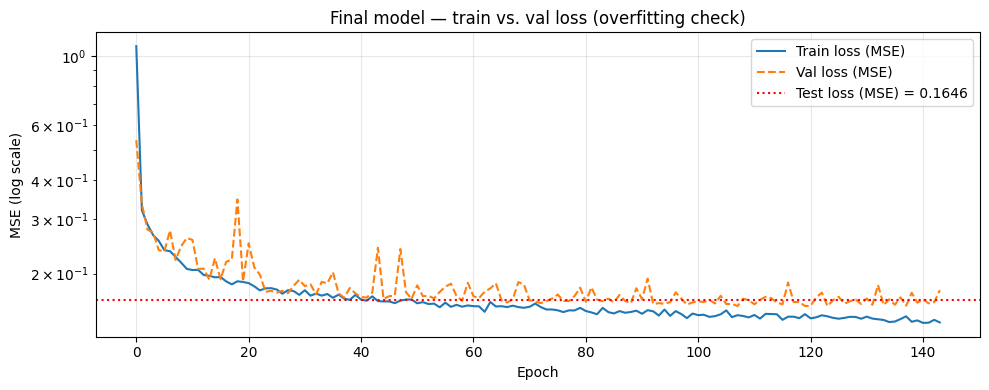

In [40]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_final.history['loss'],     label='Train loss (MSE)')
ax.plot(history_final.history['val_loss'], label='Val loss (MSE)', linestyle='--')
ax.axhline(y=test_loss, color='red', linestyle=':', label=f'Test loss (MSE) = {test_loss:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE (log scale)')
ax.set_yscale('log')
ax.set_title('Final model — train vs. val loss (overfitting check)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Sophisticated Evaluation

In [41]:
y_test_orig = df.loc[test_idx, 'trip_count'].values

def _report(name, pred_raw, y_true_raw):
    """Return a metrics dict comparing raw (count-space) predictions to truth."""
    return dict(
        model = name,
        MAE   = mean_absolute_error(y_true_raw, pred_raw),
        RMSE  = np.sqrt(mean_squared_error(y_true_raw, pred_raw)),
        MedAE = np.median(np.abs(pred_raw - y_true_raw)),
        R2    = r2_score(y_true_raw, pred_raw),
        bias  = np.mean(pred_raw - y_true_raw),
    )

# Climatology: build lookup from train only, apply to test
clim_df = df.loc[train_idx].copy()
clim_df['slot'] = clim_df['time_bucket'].dt.hour // FREQ_HOURS
clim_key = clim_df.groupby(['h3_id', 'slot', 'is_weekend'])['trip_count'].mean()

test_df = df.loc[test_idx].copy()
test_df['slot'] = test_df['time_bucket'].dt.hour // FREQ_HOURS
pred_clim = test_df.join(clim_key.rename('clim'), on=['h3_id', 'slot', 'is_weekend'])['clim'].fillna(0).values

pd.DataFrame([
    _report('climatology (cell × slot × weekend)', pred_clim,  y_test_orig),
    _report(f'FFNN tuned {BEST_HIDDEN}',           pred_final, y_test_orig),
]).set_index('model').round(3)

,MAE,RMSE,MedAE,R2,bias
model,,,,,
climatology (cell × slot × weekend),14.617,72.634,0.027,0.899,-0.432
"FFNN tuned [128, 64]",12.308,65.248,0.091,0.919,-7.109


#### Custom Demand Prediction

Predict expected trip demand for any spatio-temporal context, directly addressing 
the core business question: **"What demand can we expect on a rainy Sunday at 10am
around the outskirts of the city?"**

Fill in the variables below and run the cell. The hexagon IDs are printed first, copy the full `hex_...` string into `HEX_ID`.

In [45]:
# Available hexagon IDs:
print(df['h3_id'].unique())

# # Available hexagon IDs — copy the full hex_... string into HEX_ID below
# print(sorted(['hex_' + h for h in df['h3_id'].unique()]))

<StringArray>
['862664197ffffff', '8626641b7ffffff', '862664527ffffff', '86266452fffffff',
 '862664567ffffff', '86266456fffffff', '862664c17ffffff', '862664c1fffffff',
 '862664c87ffffff', '862664c8fffffff', '862664ca7ffffff', '862664cafffffff',
 '862664cb7ffffff', '862664cc7ffffff', '862664ccfffffff', '862664cd7ffffff',
 '862664cdfffffff', '862664ce7ffffff', '862664cefffffff', '862664cf7ffffff',
 '862664d87ffffff', '862664d8fffffff', '862664d9fffffff', '862759347ffffff',
 '86275934fffffff', '86275936fffffff']
Length: 26, dtype: string


In [50]:
# ── User-defined context ──────────────────────────────────────────────────────
HEX_ID      = 'hex_862664cc7ffffff'  # H3 hexagon id (copy from above)
HOUR_FROM   = 10                     # start hour (inclusive)
HOUR_TO     = 18                     # end hour (inclusive)
DAY_OF_WEEK = 6                      # 0=Monday … 6=Sunday
MONTH       = 7                      # 1=January … 12=December
IS_WEEKEND  = 1                      # 1=weekend, 0=weekday
IS_HOLIDAY  = 0                      # 1=public holiday, 0=normal day

# Weather
TEMPERATURE       = 28.0   # °C
APPARENT_TEMP     = 26.0   # °C (feels-like)
PRECIPITATION     = 5.0    # mm
RAIN              = 5.0    # mm
SNOWFALL          = 0.0    # cm
SNOW_DEPTH        = 0.0    # cm
WINDSPEED         = 15.0   # km/h
WINDGUSTS         = 25.0   # km/h
CLOUD_COVER       = 80.0   # %

# POI counts for the hexagon (copy from df for the chosen hex)
N_POI_ACCOMMODATION  = 2
N_POI_EDUCATION      = 1
N_POI_ENTERTAINMENT  = 5
N_POI_FOOD_NIGHTLIFE = 12
N_POI_HEALTHCARE     = 3
N_POI_SHOPPING       = 8
N_POI_TRANSPORT      = 4
# ──────────────────────────────────────────────────────────────────────────────

MONTH_NAMES = {1:'January', 2:'February', 3:'March', 4:'April', 5:'May', 6:'June',
               7:'July', 8:'August', 9:'September', 10:'October', 11:'November', 12:'December'}

pred_rows = []
for hour in range(HOUR_FROM, HOUR_TO + 1):
    query = pd.DataFrame([{col: 0.0 for col in x.columns}])

    query['hour_sin']        = np.sin(2 * np.pi * hour / 24)
    query['hour_cos']        = np.cos(2 * np.pi * hour / 24)
    query['day_of_week_sin'] = np.sin(2 * np.pi * DAY_OF_WEEK / 7)
    query['day_of_week_cos'] = np.cos(2 * np.pi * DAY_OF_WEEK / 7)
    query['month_sin']       = np.sin(2 * np.pi * (MONTH - 1) / 12)
    query['month_cos']       = np.cos(2 * np.pi * (MONTH - 1) / 12)
    query['is_weekend']      = float(IS_WEEKEND)
    query['is_holiday']      = float(IS_HOLIDAY)

    query['temperature_2m']       = TEMPERATURE
    query['apparent_temperature']  = APPARENT_TEMP
    query['precipitation']         = PRECIPITATION
    query['rain']                  = RAIN
    query['snowfall']              = SNOWFALL
    query['snow_depth']            = SNOW_DEPTH
    query['windspeed_10m']         = WINDSPEED
    query['windgusts_10m']         = WINDGUSTS
    query['cloud_cover']           = CLOUD_COVER

    query['n_poi_accommodation']  = N_POI_ACCOMMODATION
    query['n_poi_education']      = N_POI_EDUCATION
    query['n_poi_entertainment']  = N_POI_ENTERTAINMENT
    query['n_poi_food_nightlife'] = N_POI_FOOD_NIGHTLIFE
    query['n_poi_healthcare']     = N_POI_HEALTHCARE
    query['n_poi_shopping']       = N_POI_SHOPPING
    query['n_poi_transport']      = N_POI_TRANSPORT

    if HEX_ID in query.columns:
        query[HEX_ID] = 1.0
    else:
        print(f"Warning: '{HEX_ID}' not found in feature columns.")
        break

    pred = max(0.0, np.expm1(model_final.predict(scaler.transform(query), verbose=0).squeeze()))
    pred_rows.append({'hour': f'{hour:02d}:00', 'predicted_trips': round(float(pred), 1)})

result_df = pd.DataFrame(pred_rows).set_index('hour')
print(f"Hexagon: {HEX_ID} | {'Weekend' if IS_WEEKEND else 'Weekday'} | Month: {MONTH_NAMES[MONTH]}")
result_df.loc['Total'] = result_df['predicted_trips'].sum().round(1)
result_df

Hexagon: hex_862664cc7ffffff | Weekend | Month: July


,predicted_trips
hour,
10:00,3.7
11:00,5.8
12:00,6.9
13:00,7.3
14:00,7.2
15:00,6.6
16:00,4.6
17:00,2.9
18:00,1.5
